In [ ]:
import sys
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.filters import frangi
from skimage.segmentation import slic

%matplotlib inline

PROJECT_ROOT = Path.cwd().parent if (Path.cwd().name == "NoteBooks") else Path.cwd()
PREPROC_ROOT = PROJECT_ROOT / "preprocessed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("PREPROC_ROOT:", PREPROC_ROOT)


SPLIT = "train"
IMAGE_NAME = "263_D.png"

img_path = PREPROC_ROOT / SPLIT / "images" / IMAGE_NAME
fov_path = PREPROC_ROOT / SPLIT / "fov_masks" / IMAGE_NAME

print("Image path:", img_path)
print("FOV path:  ", fov_path)


N_SEGMENTS_LIST  = [1500, 3500, 4500] 
COMPACTNESS_LIST = [10.0, 6.0, 5.0]

assert len(N_SEGMENTS_LIST) == len(COMPACTNESS_LIST)
N_SCALES = len(N_SEGMENTS_LIST)

print("Scales:", list(zip(N_SEGMENTS_LIST, COMPACTNESS_LIST)))


PROJECT_ROOT: d:\Retina SEM New
PREPROC_ROOT: d:\Retina SEM New\preprocessed
Image path: d:\Retina SEM New\preprocessed\train\images\263_D.png
FOV path:   d:\Retina SEM New\preprocessed\train\fov_masks\263_D.png
Scales: [(1500, 10.0), (3500, 6.0), (4500, 5.0)]


Image shape: 1024 x 1024
Vesselness stats: min= 0.0 max= 0.13786251842975616 mean= 0.0003576354356482625


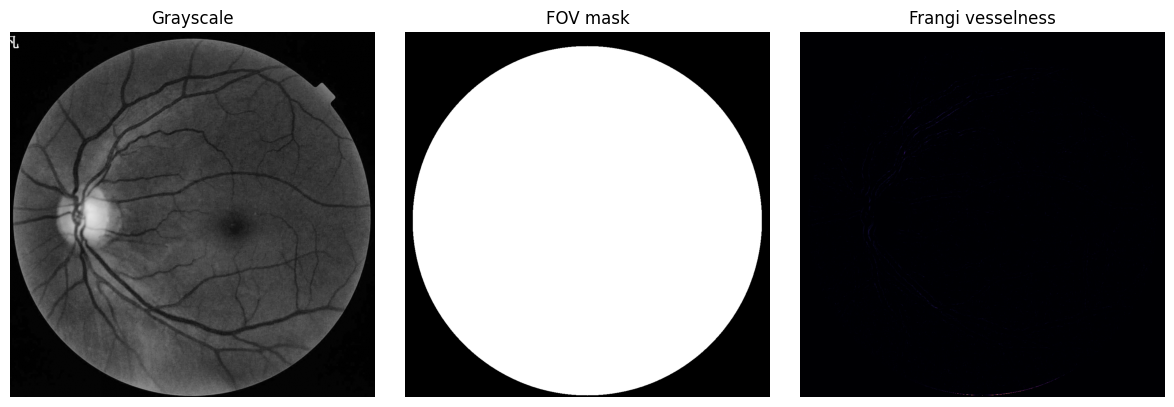

In [3]:
gray_u8 = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
if gray_u8 is None:
    raise RuntimeError(f"Could not read {img_path}")

fov_u8 = cv2.imread(str(fov_path), cv2.IMREAD_GRAYSCALE)
if fov_u8 is None:
    raise RuntimeError(f"Could not read {fov_path}")

H, W = gray_u8.shape
print("Image shape:", H, "x", W)

# Normalize to [0,1] float for filters
gray = gray_u8.astype(np.float32) / 255.0
fov  = (fov_u8 > 0).astype(np.uint8)

# Frangi vesselness on grayscale inside FOV
vesselness = frangi(gray, black_ridges=False)
vesselness[~fov.astype(bool)] = 0.0

print("Vesselness stats: min=", float(vesselness.min()),
      "max=", float(vesselness.max()),
      "mean=", float(vesselness.mean()))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(gray_u8, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(fov_u8, cmap="gray")
plt.title("FOV mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(vesselness, cmap="magma")
plt.title("Frangi vesselness")
plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
from typing import Tuple

def build_adjacency_from_labels(labels: np.ndarray) -> np.ndarray:
    """
    Build undirected edges between neighboring superpixels (4-neighborhood).
    labels: (H,W) ints 0..K-1
    Returns: edges array of shape (2, E)
    """
    H, W = labels.shape
    edges = set()

    # right neighbors
    for y in range(H):
        for x in range(W-1):
            a = int(labels[y, x])
            b = int(labels[y, x+1])
            if a != b:
                edges.add((min(a,b), max(a,b)))
    # down neighbors
    for y in range(H-1):
        for x in range(W):
            a = int(labels[y, x])
            b = int(labels[y+1, x])
            if a != b:
                edges.add((min(a,b), max(a,b)))

    if not edges:
        return np.zeros((2, 0), dtype=np.int64)

    edges = np.array(list(edges), dtype=np.int64)
    return edges.T  # shape (2, E)


def compute_node_features(gray: np.ndarray,
                          vesselness: np.ndarray,
                          labels: np.ndarray) -> np.ndarray:
    """
    features per node:
      [mean_intensity, mean_vesselness, cy_norm, cx_norm]
    """
    K = labels.max() + 1
    H, W = labels.shape

    feats = np.zeros((K, 4), dtype=np.float32)

    # Precompute sums
    counts = np.bincount(labels.ravel(), minlength=K).astype(np.float32) + 1e-6
    sum_int = np.bincount(labels.ravel(), weights=gray.ravel(), minlength=K)
    sum_v   = np.bincount(labels.ravel(), weights=vesselness.ravel(), minlength=K)

    # centroids
    yy, xx = np.indices((H, W))
    sum_y = np.bincount(labels.ravel(), weights=yy.ravel(), minlength=K)
    sum_x = np.bincount(labels.ravel(), weights=xx.ravel(), minlength=K)

    mean_int = sum_int / counts
    mean_v   = sum_v   / counts
    cy       = sum_y   / counts
    cx       = sum_x   / counts

    cy_norm = cy / H
    cx_norm = cx / W

    feats[:,0] = mean_int
    feats[:,1] = mean_v
    feats[:,2] = cy_norm
    feats[:,3] = cx_norm

    return feats


def seeds_from_intensity_vesselness(
    features: np.ndarray,
    fg_ratio: float = 0.08,
    bg_ratio: float = 0.45,
    alpha_int: float = 0.7,
):
    """
    Seeding based on a combination of mean vesselness and mean intensity.

    features: (K, 4)
      col 0 = mean intensity in [0,1]
      col 1 = mean vesselness in [0,1]

    We define a 'vessel score' = mean_vesselness - alpha_int * mean_intensity
      -> high when vesselness is high AND intensity is low (dark vessels).

    Then:
      - top fg_ratio by score => FG seeds (1)
      - bottom bg_ratio by vesselness => BG seeds (0)
      - rest => unknown (-1)
    """
    K = features.shape[0]
    mean_int = features[:, 0]
    mean_v   = features[:, 1]

    # vessel score: high vesselness, low intensity
    score = mean_v - alpha_int * mean_int

    # sort indices
    idx_score_sorted = np.argsort(score)        # ascending
    idx_v_sorted     = np.argsort(mean_v)       # ascending

    n_fg = max(1, int(fg_ratio * K))
    n_bg = max(1, int(bg_ratio * K))

    node_seeds = np.full(K, -1, dtype=np.int8)

    # BG from lowest vesselness
    bg_idx = idx_v_sorted[:n_bg]
    node_seeds[bg_idx] = 0

    # FG from highest vessel score
    fg_idx = idx_score_sorted[-n_fg:]
    node_seeds[fg_idx] = 1

    return node_seeds




def build_edge_weights(features: np.ndarray, edges: np.ndarray) -> np.ndarray:
    F = features.astype(np.float32)
    u = edges[0].astype(np.int64)
    v = edges[1].astype(np.int64)

    diff = F[u] - F[v]
    dist2 = np.sum(diff**2, axis=1)
    sigma2 = np.median(dist2) + 1e-6
    w_e = np.exp(-dist2 / sigma2).astype(np.float32)
    return w_e


def build_seed_priors(node_seeds: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    K = node_seeds.shape[0]
    s = np.full(K, 0.5, dtype=np.float32)
    s[node_seeds == 1] = 1.0
    s[node_seeds == 0] = 0.0

    w_seed = np.zeros(K, dtype=np.float32)
    w_seed[node_seeds == 1] = 1.0
    w_seed[node_seeds == 0] = 1.0
    return s, w_seed


def run_sem_optimization_stable(
    s,
    w_seed,
    edges,
    w_e,
    num_iters: int = 300,
    lr: float = 0.01,
    lam_seed: float = 2.0,
    lam_smooth: float = 3.0,
    lam_ent: float = 0.05,
):
    """
    Same SEM optimizer.
    """
    K = s.shape[0]
    x = s.copy().astype(np.float32)
    eps = 1e-4

    u = edges[0].astype(np.int64)
    v = edges[1].astype(np.int64)
    w_e = w_e.astype(np.float32)

    for it in range(num_iters):
        x = np.clip(x, eps, 1.0 - eps)
        grad = np.zeros_like(x, dtype=np.float32)

        # seed term
        grad += 2.0 * lam_seed * w_seed * (x - s)

        # smoothness term
        diff = x[u] - x[v]
        contrib = 2.0 * lam_smooth * w_e * diff
        np.add.at(grad, u, contrib)
        np.add.at(grad, v, -contrib)

        # entropy term
        ent_grad = -np.log(x / (1.0 - x))
        grad += lam_ent * ent_grad

        # normalize gradient
        gmax = float(np.max(np.abs(grad)))
        if gmax > 0:
            grad /= (gmax + 1e-6)

        x -= lr * grad

    return np.clip(x, 0.0, 1.0)


In [ ]:
prob_maps = []   # list of (H,W) prob maps, one per scale
labels_list = []

for scale_idx, (K_target, comp) in enumerate(zip(N_SEGMENTS_LIST, COMPACTNESS_LIST)):
    print(f"\n=== Scale {scale_idx+1}/{N_SCALES}: n_segments={K_target}, compactness={comp} ===")

    # SLIC superpixels on grayscale (masked by FOV)
    gray_rgb = np.dstack([gray, gray, gray])
    labels_raw = slic(
        gray_rgb,
        n_segments=K_target,
        compactness=comp,
        sigma=0,
        start_label=0,
        mask=fov.astype(bool),
    )

    #make all labels non-negative (shift so min=0)
    min_label = labels_raw.min()
    if min_label < 0:
        labels = labels_raw - min_label  
    else:
        labels = labels_raw

    labels_list.append(labels)
    K = int(labels.max() + 1)
    print("  K =", K)

    # Node features
    feats = compute_node_features(gray, vesselness, labels)

    # Adjacency
    edges = build_adjacency_from_labels(labels)
    print("  Edges:", edges.shape[1])

    # Seeds from intensity + vesselness
    node_seeds = seeds_from_intensity_vesselness(feats, fg_ratio=0.08, bg_ratio=0.45)
    print("  Seeds counts:", {v: int((node_seeds == v).sum()) for v in [-1,0,1]})


    # Edge weights + seed priors
    w_e = build_edge_weights(feats, edges)
    s, w_seed = build_seed_priors(node_seeds)

    # SEM optimization
    x_sem = run_sem_optimization_stable(
        s,
        w_seed,
        edges,
        w_e,
        num_iters=300,
        lr=0.01,
        lam_seed=2.0,
        lam_smooth=3.0,
        lam_ent=0.05,
    )
    print("  x_sem stats: min=", float(x_sem.min()),
          "max=", float(x_sem.max()),
          "mean=", float(x_sem.mean()))

    # Node -> pixel map
    prob_map = x_sem[labels]
    # mask outside FOV
    prob_map[~fov.astype(bool)] = 0.0

    prob_maps.append(prob_map.astype(np.float32))



=== Scale 1/3: n_segments=1500, compactness=10.0 ===
  K = 1491
  Edges: 4459
  Seeds counts: {-1: 797, 0: 575, 1: 119}
  x_sem stats: min= 0.0 max= 1.0 mean= 0.09803470969200134

=== Scale 2/3: n_segments=3500, compactness=6.0 ===
  K = 3463
  Edges: 10346
  Seeds counts: {-1: 1881, 0: 1305, 1: 277}
  x_sem stats: min= 0.0 max= 1.0 mean= 0.09666448086500168

=== Scale 3/3: n_segments=4500, compactness=5.0 ===
  K = 4413
  Edges: 13168
  Seeds counts: {-1: 2400, 0: 1660, 1: 353}
  x_sem stats: min= 0.0 max= 1.0 mean= 0.09232594072818756


p_avg stats:  min= 0.0 max= 1.0 mean= 0.0611921101808548
p_comp stats: min= 0.0 max= 1.0 mean= 0.0979667603969574


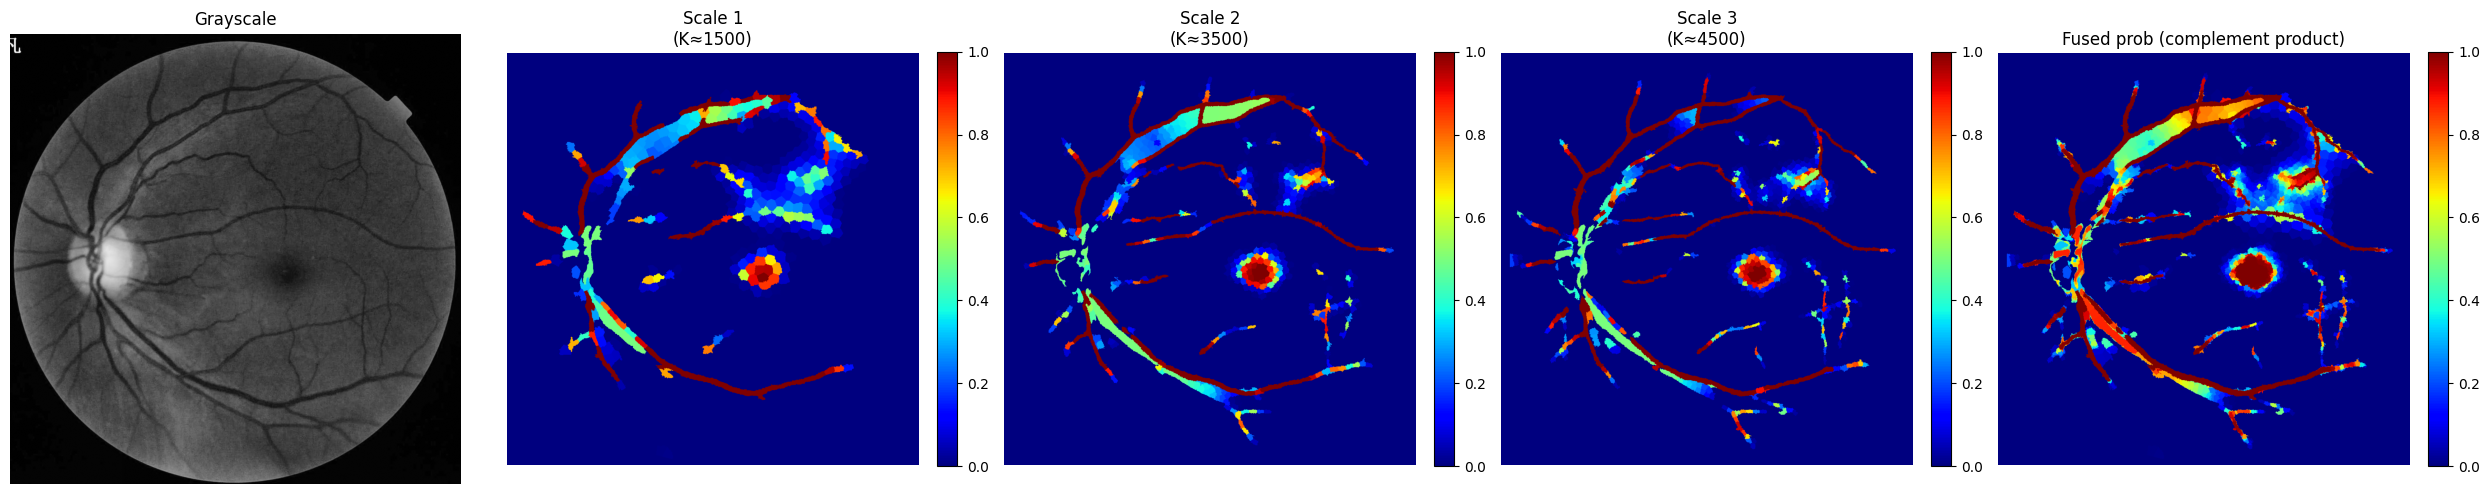

In [ ]:
# Stack to (S, H, W)
P = np.stack(prob_maps, axis=0)  # (S, H, W)

# Simple average fusion
p_avg = P.mean(axis=0)

# Complement product fusion: 1 - Π(1 - p_s)
p_comp = 1.0 - np.prod(1.0 - P, axis=0)

# Keep inside FOV only
p_avg[~fov.astype(bool)] = 0.0
p_comp[~fov.astype(bool)] = 0.0

P = np.stack(prob_maps, axis=0)  # (S, H, W)
p_avg = P.mean(axis=0)
p_avg[~fov.astype(bool)] = 0.0


print("p_avg stats:  min=", float(p_avg.min()),
      "max=", float(p_avg.max()),
      "mean=", float(p_avg.mean()))
print("p_comp stats: min=", float(p_comp.min()),
      "max=", float(p_comp.max()),
      "mean=", float(p_comp.mean()))


fig, axs = plt.subplots(1, N_SCALES+2, figsize=(5*(N_SCALES+2), 5))

axs[0].imshow(gray_u8, cmap="gray")
axs[0].set_title("Grayscale")
axs[0].axis("off")

for i in range(N_SCALES):
    im = axs[i+1].imshow(prob_maps[i], cmap="jet", vmin=0, vmax=1)
    axs[i+1].set_title(f"Scale {i+1}\n(K≈{N_SEGMENTS_LIST[i]})")
    axs[i+1].axis("off")
    plt.colorbar(im, ax=axs[i+1], fraction=0.046, pad=0.04)

im2 = axs[N_SCALES+1].imshow(p_comp, cmap="jet", vmin=0, vmax=1)
axs[N_SCALES+1].set_title("Fused prob (complement product)")
axs[N_SCALES+1].axis("off")
plt.colorbar(im2, ax=axs[N_SCALES+1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


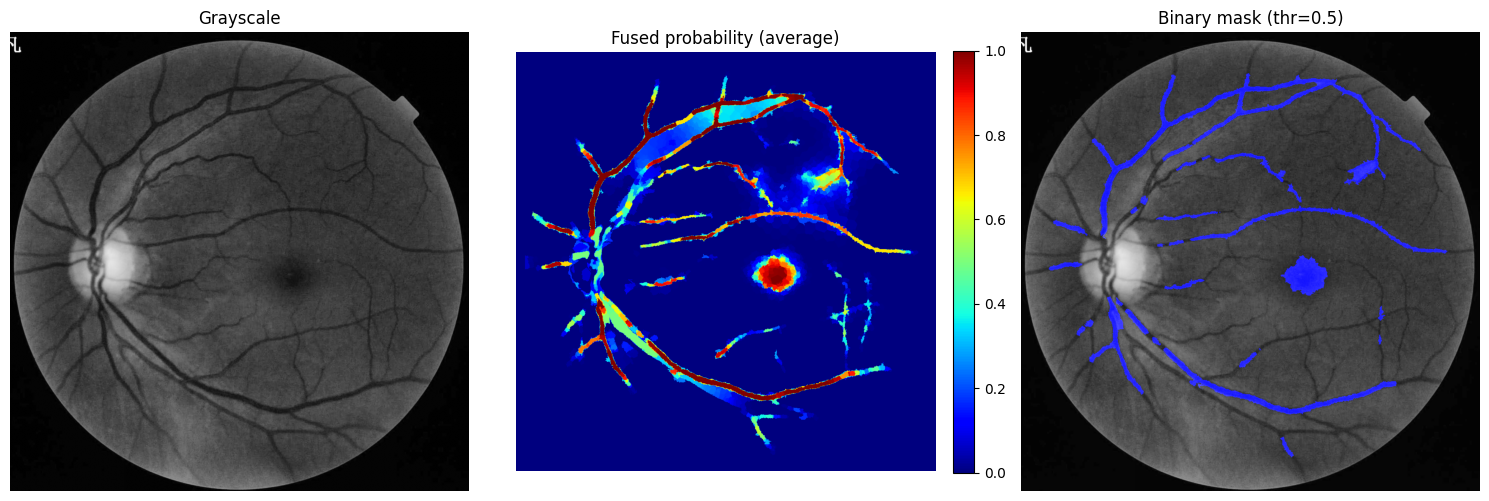

In [ ]:
THR = 0.5 

mask_bin = (p_avg >= THR).astype(np.uint8)

overlay = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR).astype(np.float32) / 255.0
overlay[mask_bin > 0, 2] = 1.0  # vessels in blue

fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].imshow(gray_u8, cmap="gray")
axs[0].set_title("Grayscale")
axs[0].axis("off")

im1 = axs[1].imshow(p_avg, cmap="jet", vmin=0, vmax=1)
axs[1].set_title("Fused probability (average)")
axs[1].axis("off")
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

axs[2].imshow(overlay)
axs[2].set_title(f"Binary mask (thr={THR})")
axs[2].axis("off")

plt.tight_layout()
plt.show()


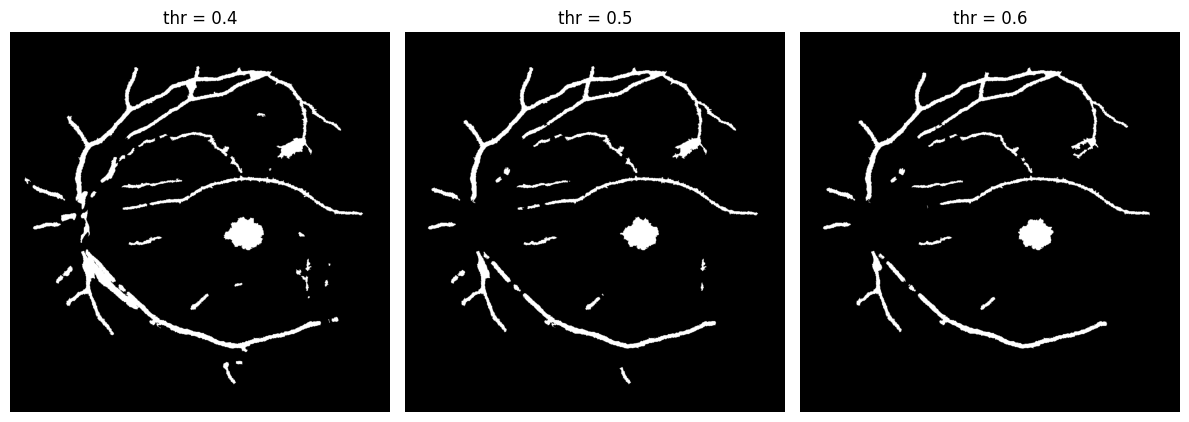

In [ ]:
# Display multi-threshold vessel masks

import matplotlib.pyplot as plt
import numpy as np

prob = p_avg.copy()

thresholds = [0.40, 0.50, 0.60]

fig, axes = plt.subplots(1, len(thresholds), figsize=(4*len(thresholds), 5))

for ax, thr in zip(axes, thresholds):

    # Create binary mask: 1 = vessel, 0 = background
    mask = (prob >= thr).astype(np.uint8)

    # Show binary mask (white vessels, black background)
    ax.imshow(mask, cmap="gray")
    ax.set_title(f"thr = {thr}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import cv2
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score
from skimage.morphology import skeletonize


split    ="train"
img_name ="263_D.png"


gt_path = PROJECT_ROOT / "dataset" / split / "Ground truth" / img_name
gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
if gt_mask is None:
    raise RuntimeError(f"Could not read GT mask at {gt_path}")

gt_bin = (gt_mask > 0).astype(np.uint8)

# Resize GT to match p_avg resolution 
h_p, w_p = p_avg.shape
if gt_bin.shape != p_avg.shape:
    print(f"Resizing GT from {gt_bin.shape} to {p_avg.shape} for evaluation")
    gt_bin = cv2.resize(gt_bin, (w_p, h_p), interpolation=cv2.INTER_NEAREST)


thresholds = [0.40, 0.50, 0.60]

# PR-AUC (Precision–Recall AUC, threshold-free)
y_true  = gt_bin.ravel().astype(np.uint8)
y_score = p_avg.ravel().astype(np.float32)
pr_auc  = average_precision_score(y_true, y_score)

# clDice
def cldice_score(pred_bin: np.ndarray, gt_bin: np.ndarray, eps: float = 1e-6) -> float:
    pred = pred_bin.astype(bool)
    gt   = gt_bin.astype(bool)
    if pred.sum() == 0 or gt.sum() == 0:
        return 0.0

    skel_pred = skeletonize(pred)
    skel_gt   = skeletonize(gt)

    t_prec = (skel_pred & gt).sum() / (skel_pred.sum() + eps)
    t_sens = (skel_gt & pred).sum() / (skel_gt.sum() + eps)

    return 2.0 * t_prec * t_sens / (t_prec + t_sens + eps)

rows = []

for thr in thresholds:
    pred_bin = (p_avg >= thr).astype(np.uint8)

    tp = int(((pred_bin == 1) & (gt_bin == 1)).sum())
    fp = int(((pred_bin == 1) & (gt_bin == 0)).sum())
    fn = int(((pred_bin == 0) & (gt_bin == 1)).sum())

    dice = 2.0 * tp / (2.0 * tp + fp + fn + 1e-6)
    cld  = cldice_score(pred_bin, gt_bin)

    rows.append({
        "threshold": thr,
        "Dice":      dice,
        "clDice":    cld,
        "PR-AUC":    pr_auc,
    })

metrics_df = pd.DataFrame(rows)
display(metrics_df)


Resizing GT from (2048, 2048) to (1024, 1024) for evaluation


,threshold,Dice,clDice,PR-AUC
0,0.4,0.559834,0.519674,0.553216
1,0.5,0.541125,0.491055,0.553216
2,0.6,0.518861,0.463752,0.553216
